In [10]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["lines.markersize"]=0.7
plt.rcParams["axes.unicode_minus"]=True
plt.rcParams["font.size"]=10
plt.rcParams["text.usetex"]=True
plt.rcParams["font.serif"]="Computer Modern Serif"

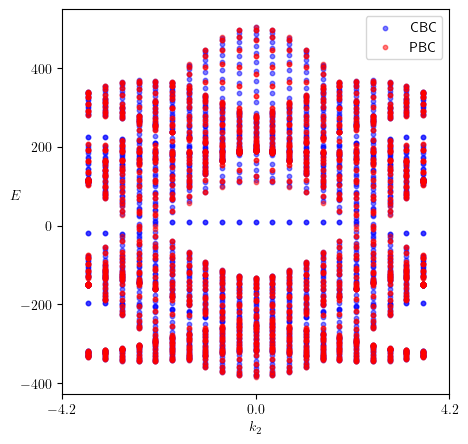

In [17]:
periodic = np.load('periodic.npy')
cylindric = np.load('cylindric.npy')
grid_size = periodic.shape[0]-1
k_size = grid_size
REZI_2 = 2*np.pi/np.sqrt(3)*np.array([-1,np.sqrt(3),0])   
kx = np.arange(-(k_size//2),k_size//2+1)/k_size*np.linalg.norm(REZI_2)#/k_size * k1[0]

fig, ax = plt.subplots(figsize=(5, 5))
for j in range(0*grid_size,6*grid_size):
    # ax.scatter(kx, eigenvals[ :, j], color='blue', s=10, alpha=0.5)
    cyl = ax.scatter(kx, cylindric[ :, j,0], color='blue', s=10, alpha=0.5)


for h in range(6):
    for j in range(k_size):
        per = ax.scatter(kx, periodic[ j,:,h,0], color='red', s=10, alpha=0.5)
        # ax.scatter(kx, eigenvals3[ j,:,h], color='blue', s=10, alpha=0.5)

ax.set_xticks([-4.2,0,4.2])
ax.set_xlabel(r"$k_2$")
ax.set_ylabel(r"$E$",rotation=0)
ax.legend([cyl,per],['CBC','PBC'])
plt.show()

(-17.502861-1.711507e-15j)


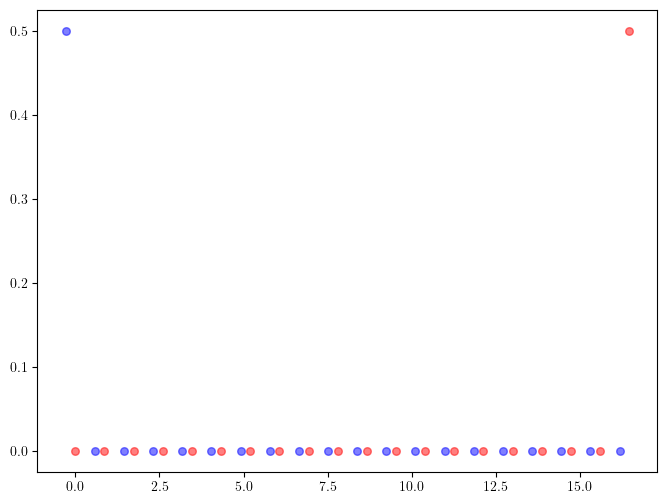

(-18.192066+1.57524e-05j)


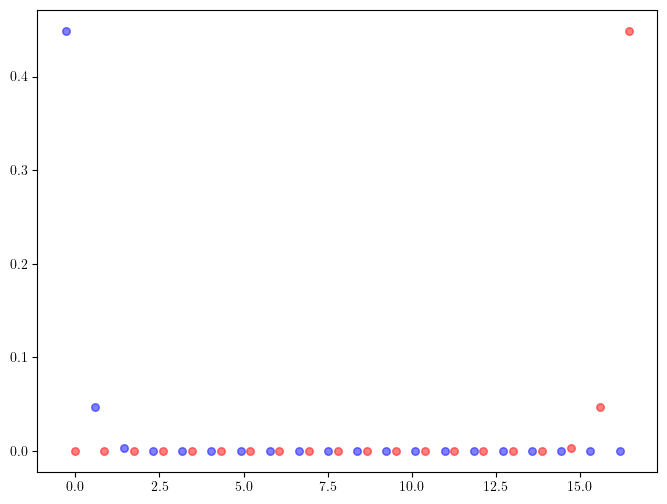

(-20.191603-3.8984686e-05j)


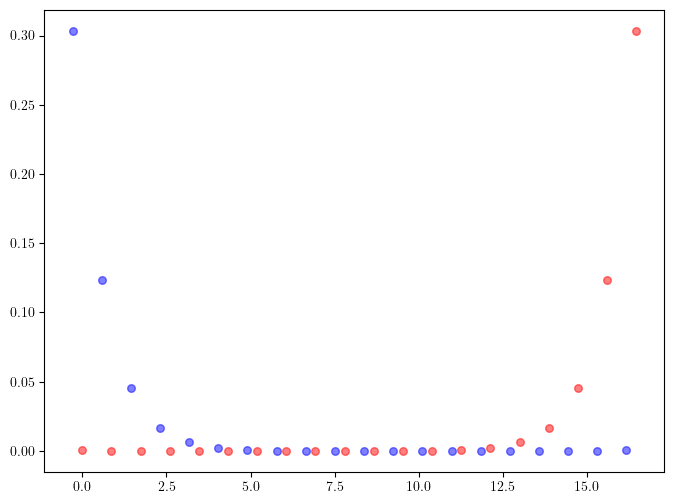

(-3.589764-0.00013953698j)


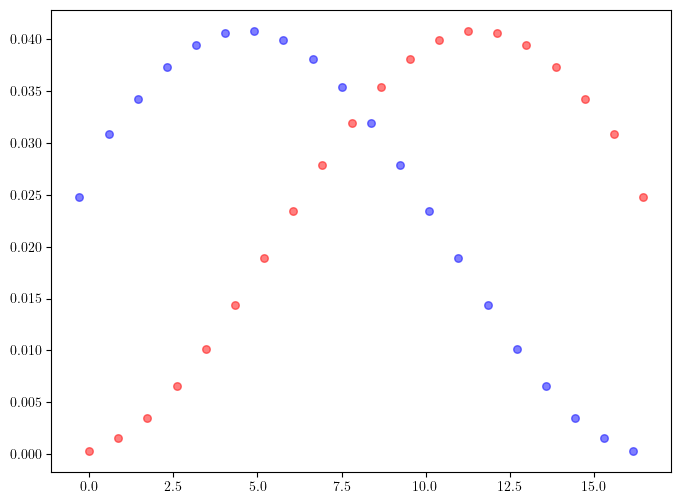

(4.924023-6.6944986e-06j)


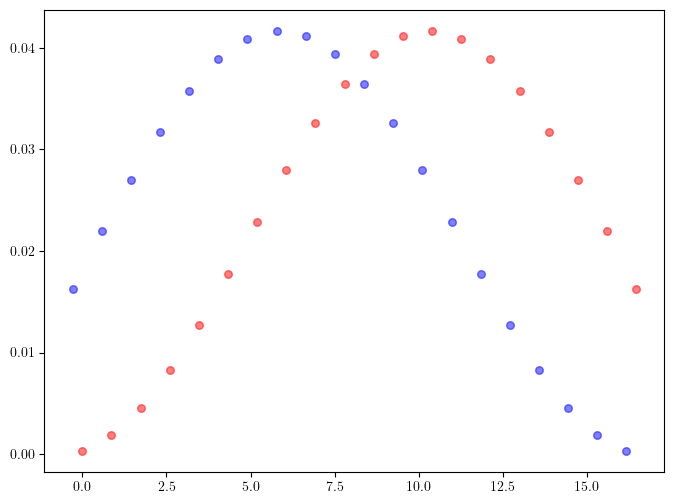

(9.663071-7.440848e-06j)


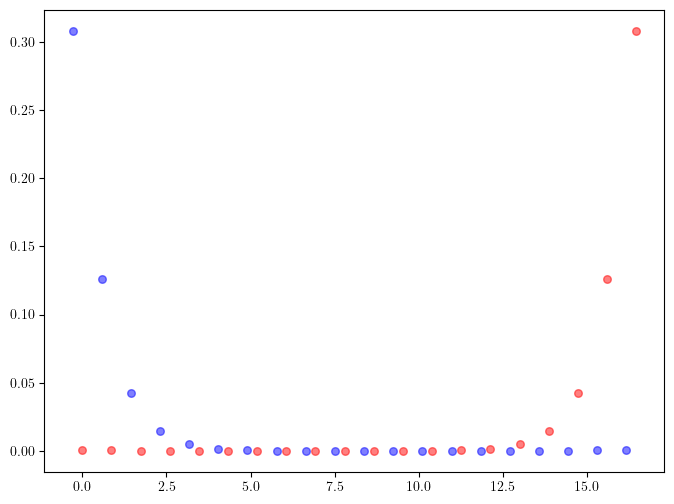

(8.86688+1.1141519e-06j)


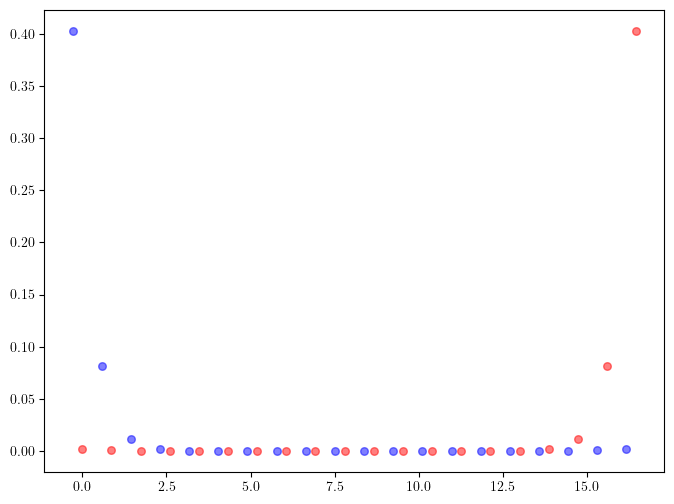

(8.806939+3.3837557e-07j)


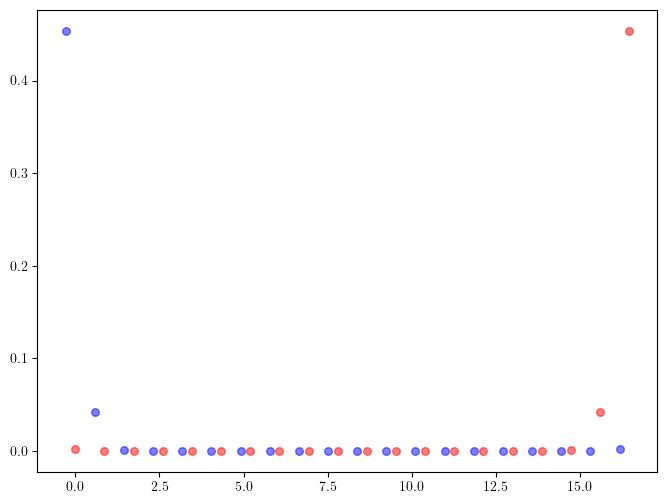

(9.279155-2.4581144e-07j)


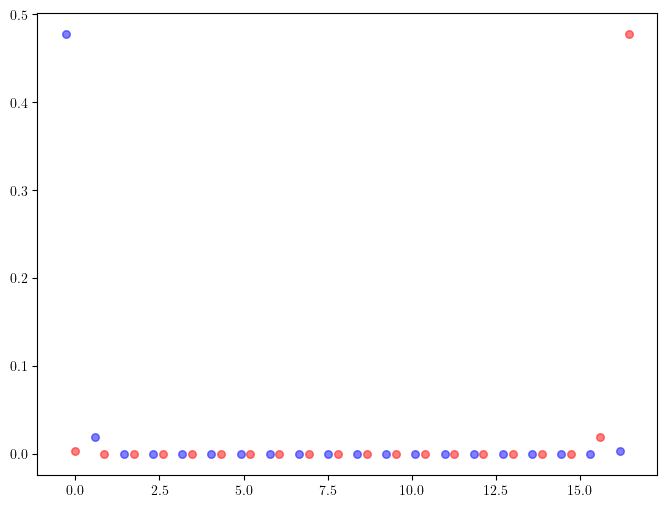

(9.860111+8.09087e-08j)


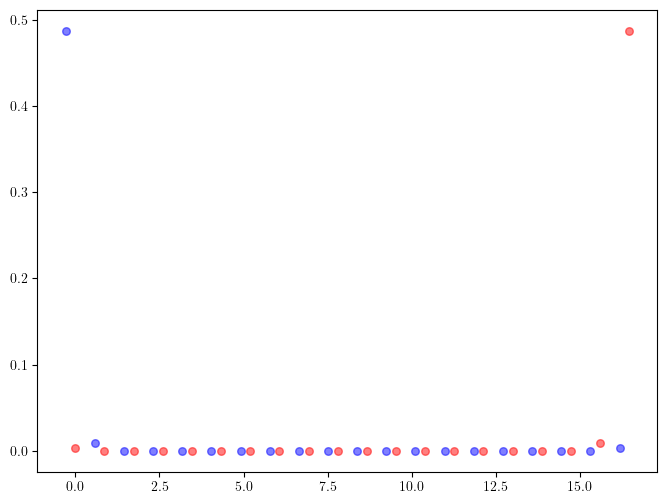

(10.117329+0j)


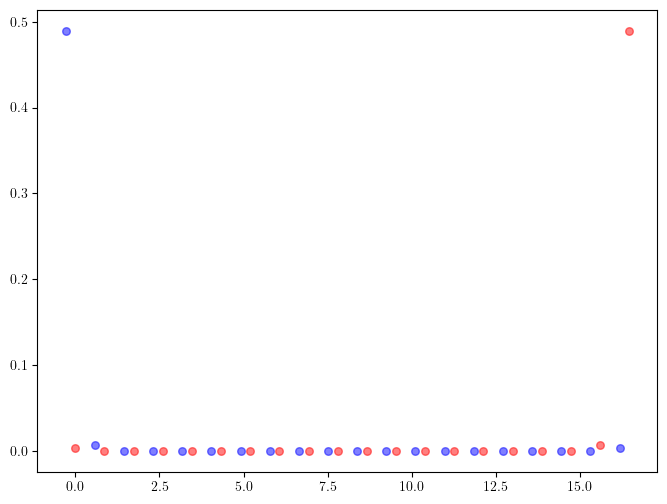

(9.860111-8.09087e-08j)


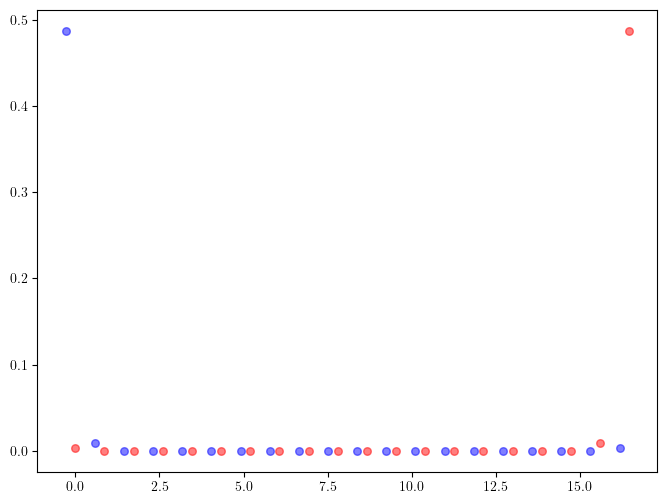

(9.279155+2.4581144e-07j)


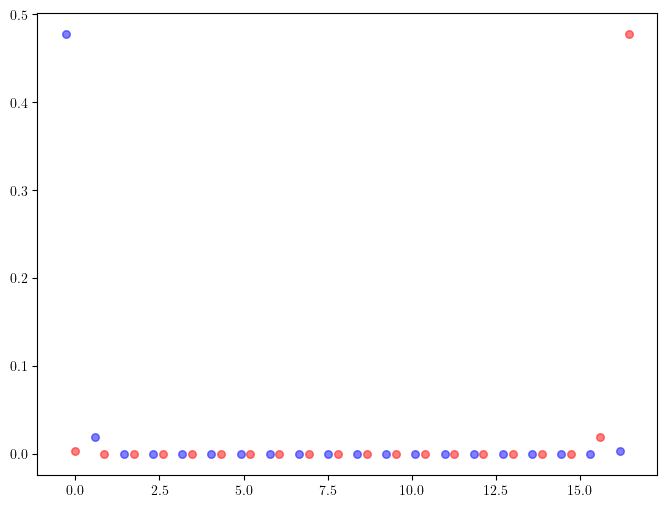

(8.806939-3.3837557e-07j)


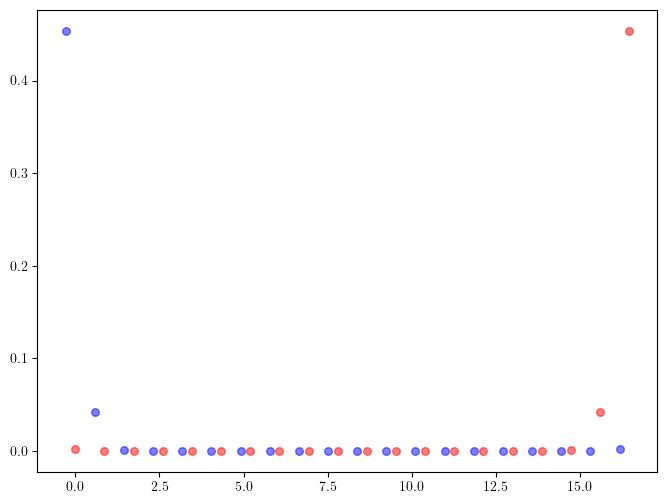

(8.86688-1.1141519e-06j)


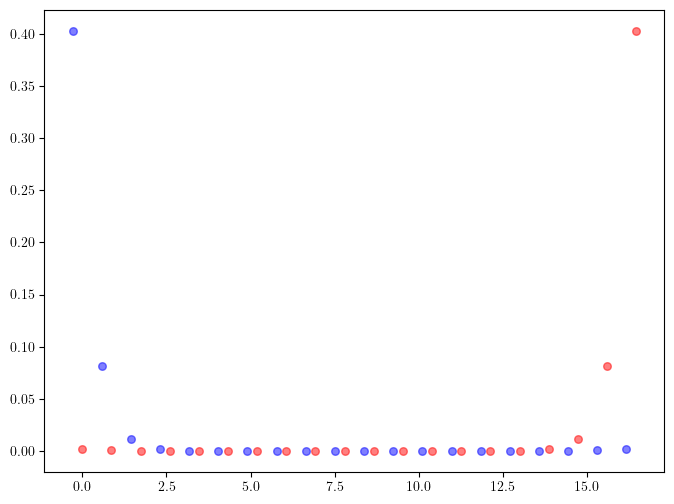

(9.663071+7.440848e-06j)


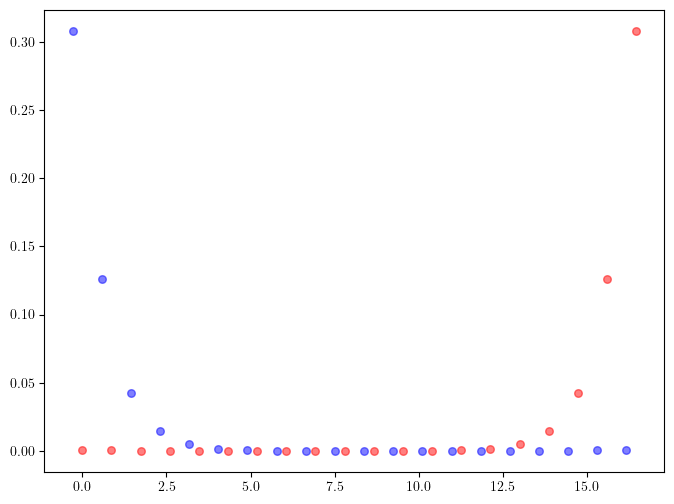

(4.924023+6.6944986e-06j)


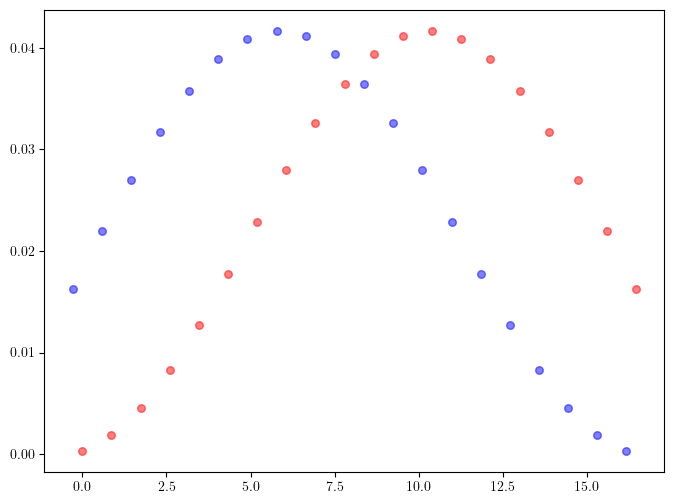

(-3.589764+0.00013953698j)


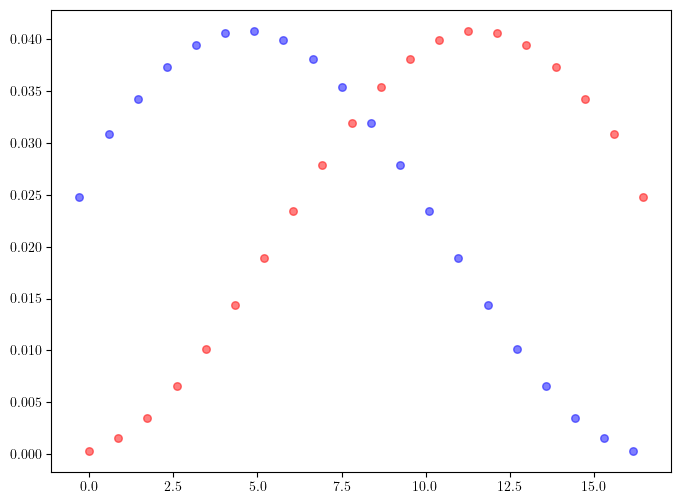

(-20.191603+3.8984686e-05j)


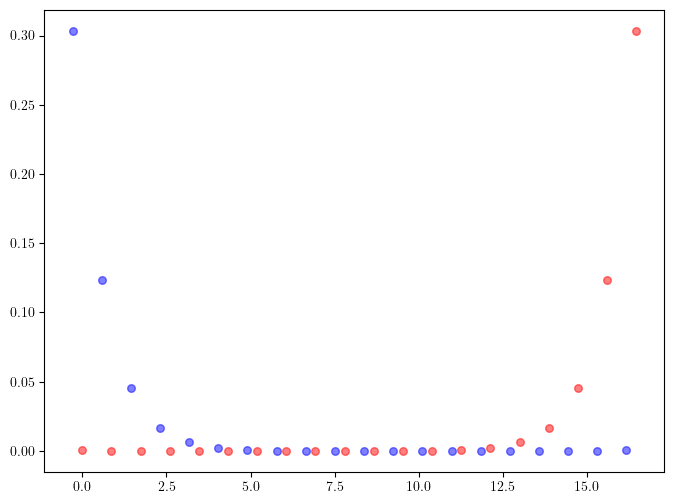

(-18.192066-1.57524e-05j)


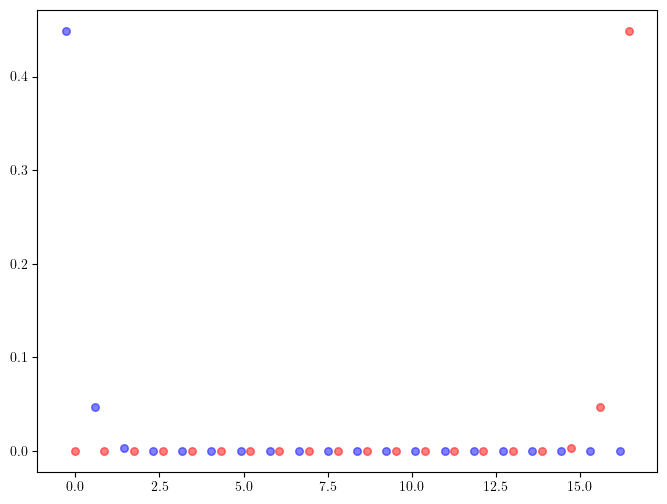

(-17.502861+1.711507e-15j)


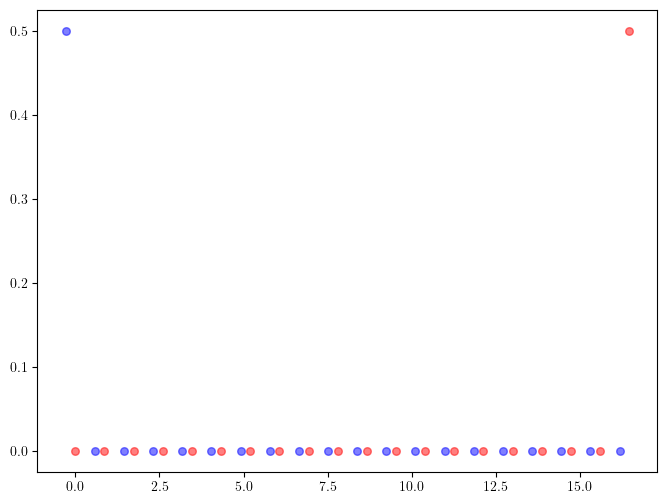

In [21]:
# print eigenstates cylindric boundiary conditions
for i in range(len(kx)):
    fig, ax = plt.subplots(figsize=(8,6))
    index = np.argmin(np.abs(np.real(cylindric[i,:,0])))
    print(cylindric[i,index,0])
    vecA = np.abs(cylindric[i,index,1:grid_size+1])**2+np.abs(cylindric[i,index,grid_size+1:2*grid_size+1])**2+np.abs(cylindric[i,index,2*grid_size+1:3*grid_size+1])**2
    vecB = np.abs(cylindric[i,index,3*grid_size+1:4*grid_size+1])**2+np.abs(cylindric[i,index,4*grid_size+1:5*grid_size+1])**2+np.abs(cylindric[i,index,5*grid_size+1:6*grid_size+1])**2
    
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3),vecA[::2],color='red',s=30,alpha=0.5)
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3)+1/2*np.sqrt(3),vecA[1::2],color='red',s=30,alpha=0.5)
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3)-1/2/np.sqrt(3),vecB[::2],color='blue',s=30,alpha=0.5)
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3)+1/np.sqrt(3),vecB[1::2],color='blue',s=30,alpha=0.5)
    plt.show()

In [12]:
# interaction and lattice definition

BASE_A = np.zeros(3)
BASE_B = np.array([1/np.sqrt(3),0,0])
LATTICE_VECTOR_2 = np.array([0,1,0])
LATTICE_VECTOR_1 = 1/2*np.array([np.sqrt(3),1,0])
LATTICE_VECTOR_1_ALTERNATIVE = np.sqrt(3)*np.array([1,0,0])

REZI_2 = 2*np.pi/np.sqrt(3)*np.array([-1,np.sqrt(3),0])   
REZI_1 = 4*np.pi/np.sqrt(3)*np.array([1,0,0])
# alternative can't be used, gives wrong results
REZI_1_ALTERNATIVE = 2*np.pi/np.sqrt(3)*np.array([1,0,0])
REZI_2_ALTERNATIVE = 2*np.pi*np.array([0,1,0])


def bare_interaction(Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5
        if i == 2:
            potential += 6/ Del_R**5
    potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return potential

def bare_interaction_coulomb(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    beta = 0.04
    potential = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R >interaction_radius+0.01:
        return 0
    if i==j:
        # return 0
        potential += 1
    potential -= 3*Delta_R_vec[i]*Delta_R_vec[j]/Del_R**2
    potential *= beta/2/Del_R**3
    return potential
        

def bare_interaction_coulomb_onsite(i: int, j:int) -> float:
    Vb = -0.1
    if i ==2 or j==2:
        return 0
    elif i == j:
        return 1
    elif i ==0:
        return -1j*Vb
    else:
        return 1j*Vb
    
def no_onsite_interaction(i: int, j:int) -> float:
    return 0

b = 4*np.pi/3/np.sqrt(3)
k3 = b*np.array([np.sqrt(3)/4,3/4,0])
k1 = 2*np.pi/3*np.array([-1,np.sqrt(3),0])   
k2 = 4*np.pi/3*np.array([1,0,0])

def k_course(t: float) -> np.ndarray:
    """Calculate the k vector based on the time parameter t."""
    if t < 1/3:
        return (1-t*3) * k3
    elif t < 2/3:
        return (t-1/3)*3* k2
    else:
        return (t-2/3)*3 * (k3-k2) + k2

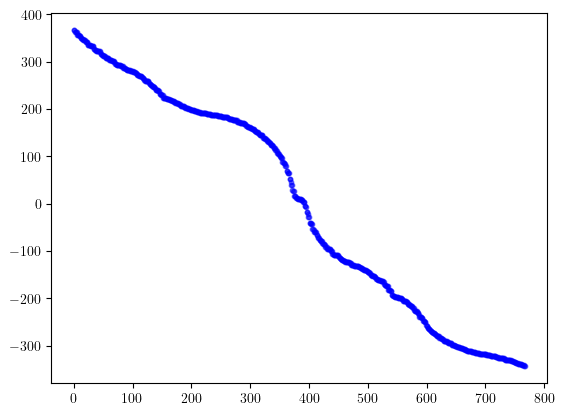

In [13]:
# open lattice consideration
def mat_size(n):
    # return 2*((n+1)*(n-1)+n*(n-1)+2*n**2)
    # return 2*((n+1)*n+n**2+(n+2)*n+n)
    # return 2*((n+1)**2+(n-1)*(n+1)/2+3/2*(n+1)-n-1)
    return 2*((n+1)**2+n//2+n*(n//2+1)-n-1)

def open_D_mat(grid_size,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((3,mat_size(grid_size)*3))
    latticeB = np.zeros_like(latticeA)
    BASE_B2 = 1/np.sqrt(3)*np.array([-1/2, np.sqrt(3)/2, 0])
    LATTICE_VECTOR_1_DOWN = 1/2*np.array([np.sqrt(3),-1,0])
    BASE_A2 = LATTICE_VECTOR_1
    edge_A = []
    edge_B = []
    count = -1
    for j in range(grid_size+1):
        edge_B.append(count+1)
        for i in range(grid_size+1):
            count += 1

            latticeA[:,count] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
            latticeB[:,count] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        edge_A.append(count)
    for j in range(grid_size):
        edge_A.append(count+1)
        for i in range(grid_size+1):
            count += 1
            latticeA[:,count] = LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
            latticeB[:,count] = BASE_B+ LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        edge_B.append(count)


    for i in range(grid_size+1):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range(i//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A+  i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2


    for i in range(grid_size):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range((grid_size-i-1)//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN*(grid_size+1)+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A+ LATTICE_VECTOR_1_DOWN*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2


    for i in range(grid_size+1):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range(i//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2 +  i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2

    for i in range(grid_size):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range((grid_size-i-1)//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+  LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1*(grid_size+1) + LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2+ LATTICE_VECTOR_1*grid_size+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2
    

    latticeA = latticeA[:,:count+1]
    latticeB = latticeB[:,:count+1]
    dmat = np.zeros((4*(count+1),4*(count+1)),dtype=complex)
    if not cut:
        cut = [grid_size*4/9*np.sqrt(3)]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(count+1):
                    for m in range(count+1):
                        if n==m:
                            dmat[i*(count+1)+n,j*(count+1)+m] = onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i,j,*cut)
            if i >=2 and j>=2:
                for n in range(count+1):
                    for m in range(count+1):
                        if n==m:
                            dmat[i*(count+1)+n,j*(count+1)+m] = onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i-2,j-2,*cut)
            if i <2 and j>=2:
                for n in range(count+1):
                    for m in range(count+1):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i,j-2,*cut)
            if i >=2 and j<2:
                for n in range(count+1):
                    for m in range(count+1):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i-2,j,*cut)
    return dmat, latticeA, latticeB, latticeA.shape[1], edge_A, edge_B


# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
dmat, latticeA, latticeB, lattice_size, edge_A, edge_B = open_D_mat(7,bare_interaction,no_onsite_interaction,100)
eig, vecs = np.linalg.eig(dmat)

fig, ax = plt.subplots(1,1)
ax.scatter(np.arange(eig.shape[0]), sorted(np.real(eig))[::-1], color='blue', s=10, alpha=0.5)
plt.show()


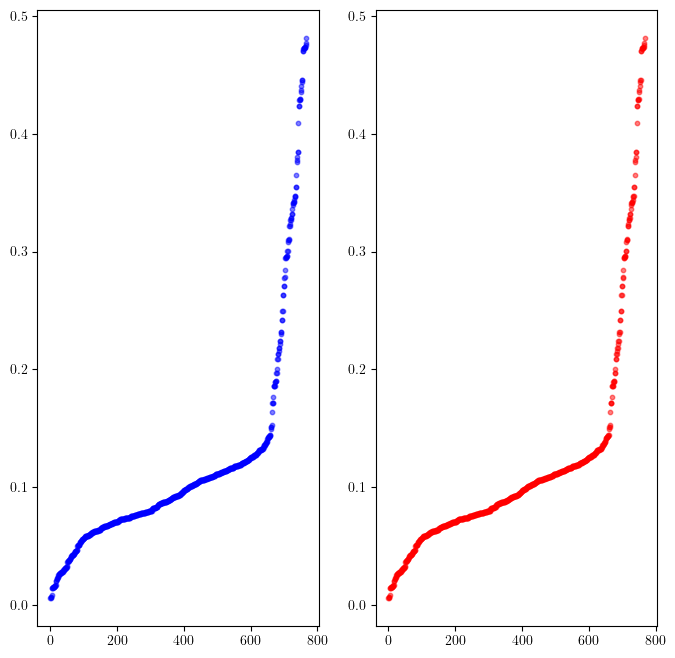

In [ ]:
def sum_edge(state, edge_A, edge_B):
    sum_A = 0
    sum_B = 0
    for i in range(len(edge_A)):
        sum_A += np.abs(state[edge_A[i]])**2 + np.abs(state[edge_A[i]+lattice_size])**2
    for i in range(len(edge_B)):
        sum_B += np.abs(state[edge_B[i]+2*lattice_size])**2 + np.abs(state[edge_B[i]+lattice_size*3])**2
    return sum_A, sum_B

def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)


# vecs = sort_eigenvalues(eig,vecs)

fig, ax = plt.subplots(1,2,figsize=(8, 8))
edge_pops_A = []
edge_pops_B = []
for n in range(eig.shape[0]):
    ea,eb = sum_edge(vecs[n,1:], edge_A, edge_B)
    edge_pops_A.append(ea)
    edge_pops_B.append(eb)
ax[0].scatter(np.arange(eig.shape[0]), sorted(edge_pops_A), color='blue', s=10, alpha=0.5)
ax[1].scatter(np.arange(eig.shape[0]), sorted(edge_pops_B), color='red', s=10, alpha=0.5)

energy:  (9.44595317865484+0j)


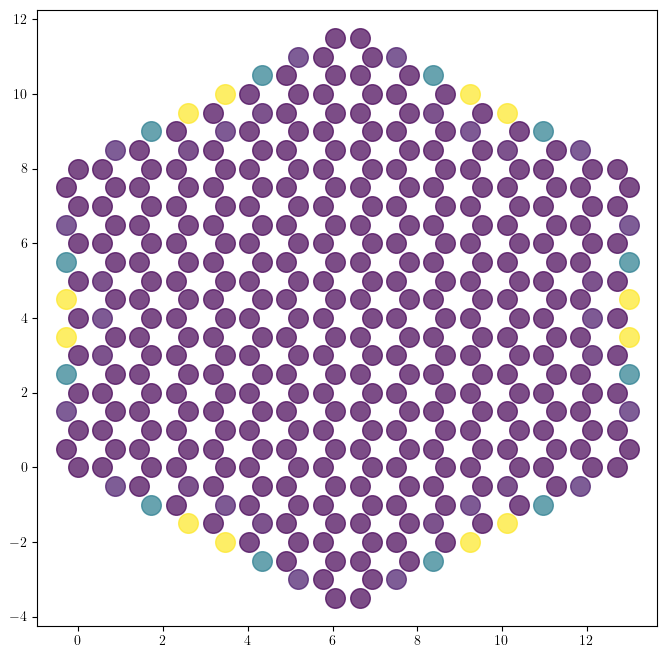

energy:  (9.794483715914879+0j)


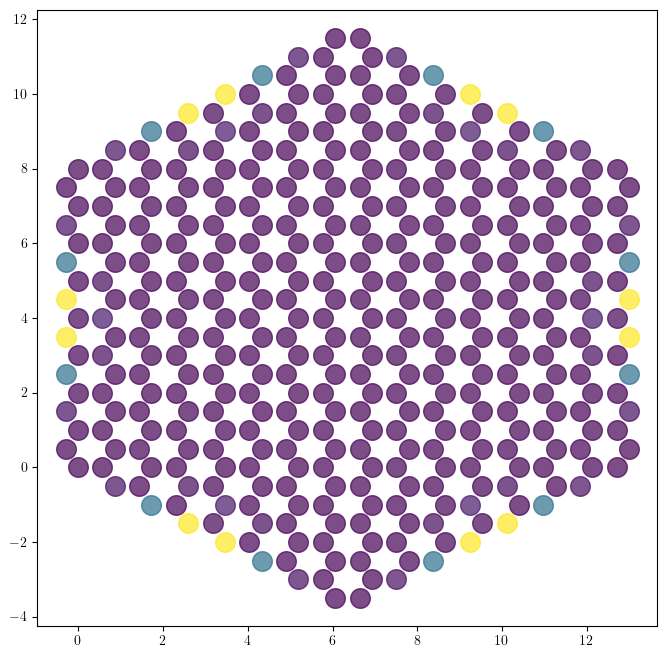

energy:  (197.63546504205317-0j)


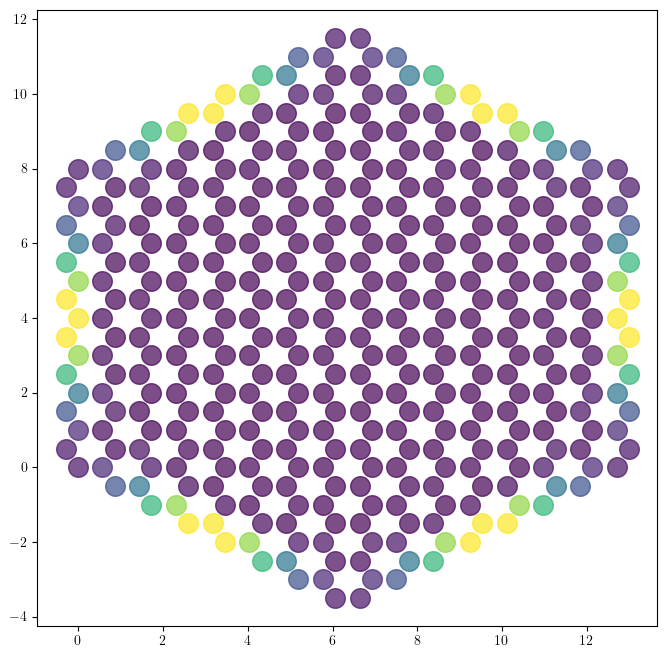

energy:  (9.771527865742819+0j)


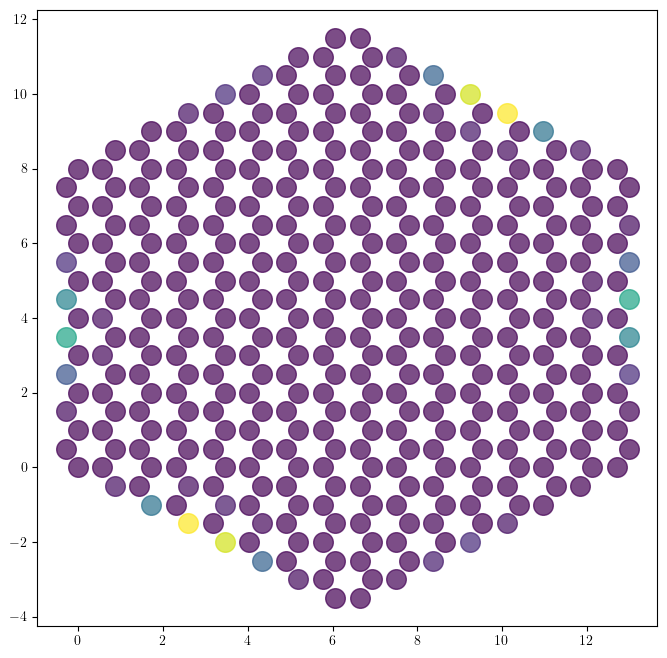

energy:  (9.771527865742032+0j)


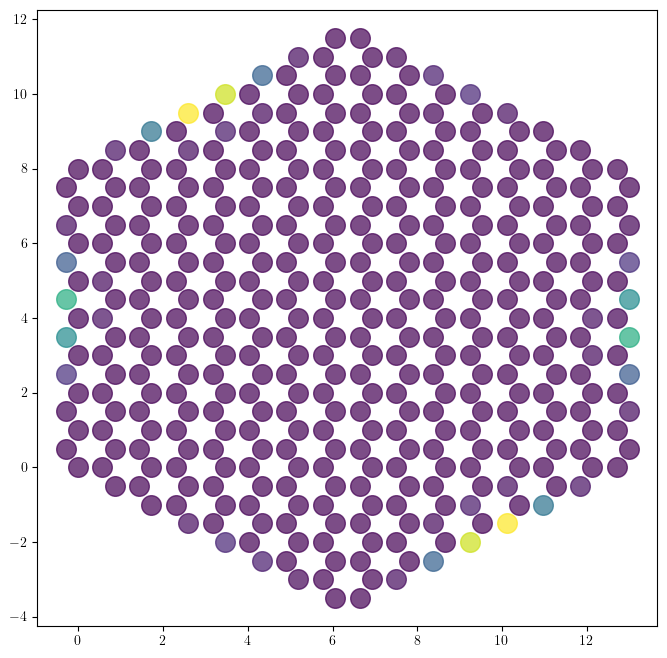

energy:  (197.6830614788709-0j)


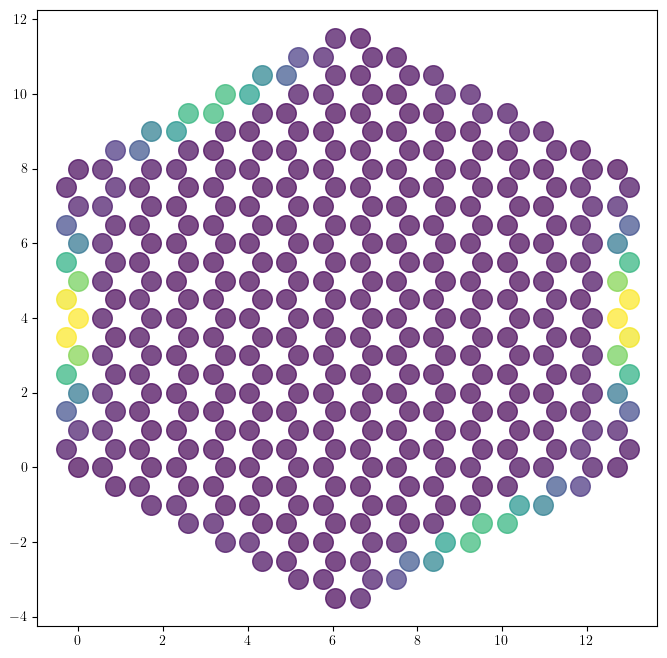

In [20]:

edge_statesA = sort_eigenvalues(np.array(edge_pops_A), vecs.T)
# edge_statesB = sort_eigenvalues(np.array(edge_pops_B), vecs.T)
from matplotlib import colormaps
cmap = colormaps['viridis']
for n in range(6):
    print("energy: ",edge_statesA[-1-n,1])
    fig, ax = plt.subplots(1,1,figsize=(8, 8))
    state = edge_statesA[-1-n,2:]
    state = np.abs(state)**2
    state = np.concatenate((state[:lattice_size]+state[lattice_size:2*lattice_size], state[2*lattice_size:3*lattice_size]+state[3*lattice_size:]))
    state = state/np.max(state)
    stateA = state[:lattice_size]
    for i in range(lattice_size):
        ax.scatter(latticeA[0,i], latticeA[1,i], color=cmap(state[i]), s=200, alpha=0.7)
        ax.scatter(latticeB[0,i], latticeB[1,i], color=cmap(state[i+lattice_size]), s=200, alpha=0.7)

    plt.show()